# HW08-09 - PyTorch MLP: регуляризация и оптимизация

## 1. Импорты

In [1]:
import copy
import json
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from IPython.display import display
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42
BASE_DIR = Path('homeworks/HW08-09') if Path('homeworks/HW08-09').exists() else Path('.')
ARTIFACTS_DIR = BASE_DIR / 'artifacts'
FIGURES_DIR = ARTIFACTS_DIR / 'figures'
MPL_CONFIG_DIR = Path(os.environ.get('MPLCONFIGDIR', '/tmp/hw0809-mpl-cache'))
DEFAULT_DATA_ROOT = BASE_DIR / '.cache' / 'emnist'
DATA_ROOT = Path(os.environ.get('HW0809_DATA_ROOT', str(DEFAULT_DATA_ROOT)))

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MPL_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ['MPLCONFIGDIR'] = str(MPL_CONFIG_DIR)

import matplotlib.pyplot as plt

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.use_deterministic_algorithms(True, warn_only=True)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device_request = os.environ.get('HW0809_DEVICE', 'cpu').lower()
if device_request == 'cpu':
    device = torch.device('cpu')
elif device_request == 'auto':
    if torch.cuda.is_available():
        device = torch.device('cuda')
    elif getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        device = torch.device('mps')
    else:
        device = torch.device('cpu')
elif device_request == 'cuda':
    if not torch.cuda.is_available():
        raise RuntimeError('HW0809_DEVICE=cuda, but CUDA is unavailable.')
    device = torch.device('cuda')
elif device_request == 'mps':
    if getattr(torch.backends, 'mps', None) is None or not torch.backends.mps.is_available():
        raise RuntimeError('HW0809_DEVICE=mps, but MPS is unavailable.')
    device = torch.device('mps')
else:
    raise ValueError(f'Unsupported HW0809_DEVICE: {device_request}')

BATCH_SIZE = 256 if device.type in {'cuda', 'mps'} else 128
NUM_WORKERS = 0

print({'seed': SEED, 'device_request': device_request, 'device': device.type, 'batch_size': BATCH_SIZE, 'data_root': str(DATA_ROOT)})

Matplotlib is building the font cache; this may take a moment.


{'seed': 42, 'device_request': 'cpu', 'device': 'cpu', 'batch_size': 128, 'data_root': '.cache/emnist'}


## 2. Данные и DataLoader
Для датасета используем стандартные `torchvision` train/test split.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_full = datasets.EMNIST(
    root=str(DATA_ROOT),
    split='balanced',
    train=True,
    download=not (DATA_ROOT / 'EMNIST').exists(),
    transform=transform,
)
test_dataset = datasets.EMNIST(
    root=str(DATA_ROOT),
    split='balanced',
    train=False,
    download=False,
    transform=transform,
)

train_len = int(len(train_full) * 0.8)
val_len = len(train_full) - train_len
train_dataset, val_dataset = random_split(
    train_full,
    [train_len, val_len],
    generator=torch.Generator().manual_seed(SEED),
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
    num_workers=NUM_WORKERS,
)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

class_names = train_full.classes
sample_x, sample_y = next(iter(train_loader))
input_dim = int(np.prod(sample_x.shape[1:]))
num_classes = len(class_names)

sanity_df = pd.DataFrame({
    'item': ['train_size', 'val_size', 'test_size', 'batch_x_shape', 'batch_y_shape', 'x_min', 'x_max', 'num_classes'],
    'value': [
        len(train_dataset),
        len(val_dataset),
        len(test_dataset),
        tuple(sample_x.shape),
        tuple(sample_y.shape),
        float(sample_x.min()),
        float(sample_x.max()),
        num_classes,
    ],
})
display(sanity_df)

100.0%


,item,value
0,train_size,90240
1,val_size,22560
2,test_size,18800
3,batch_x_shape,"(128, 1, 28, 28)"
4,batch_y_shape,"(128,)"
5,x_min,-1.0
6,x_max,1.0
7,num_classes,47


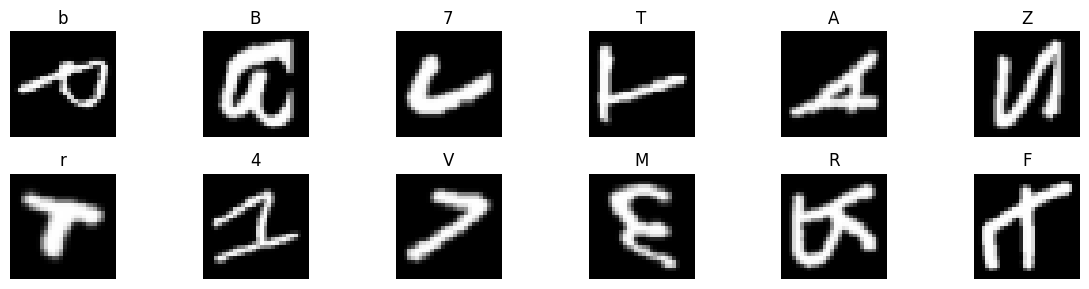

In [3]:
plt.figure(figsize=(12, 3))
for idx in range(12):
    plt.subplot(2, 6, idx + 1)
    image = sample_x[idx].squeeze(0).numpy()
    image = image * 0.5 + 0.5
    plt.imshow(image, cmap='gray')
    plt.title(str(class_names[int(sample_y[idx])]))
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Модель и вспомогательные функции

MLP, train/eval цикл и EarlyStopping. Лучшие веса храним отдельно

In [4]:
def activation_layer(name: str) -> nn.Module:
    if name == 'relu':
        return nn.ReLU()
    if name == 'gelu':
        return nn.GELU()
    raise ValueError(f'Unsupported activation: {name}')


class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        hidden_dims: tuple[int, ...],
        num_classes: int,
        activation: str = 'relu',
        dropout_p: float = 0.0,
        use_batchnorm: bool = False,
    ) -> None:
        super().__init__()
        layers: list[nn.Module] = [nn.Flatten()]
        in_features = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(in_features, hidden_dim))
            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(activation_layer(activation))
            if dropout_p > 0:
                layers.append(nn.Dropout(dropout_p))
            in_features = hidden_dim

        layers.append(nn.Linear(in_features, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x)


class EarlyStopping:
    def __init__(self, patience: int = 3, min_delta: float = 0.0) -> None:
        self.patience = patience
        self.min_delta = min_delta
        self.best_score: float | None = None
        self.best_state: dict[str, torch.Tensor] | None = None
        self.best_epoch = 0
        self.counter = 0

    def step(self, score: float, model: nn.Module, epoch: int) -> bool:
        improved = self.best_score is None or score > self.best_score + self.min_delta
        if improved:
            self.best_score = float(score)
            self.best_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
            self.best_epoch = epoch
            self.counter = 0
            return False

        self.counter += 1
        return self.counter >= self.patience


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    for x_batch, y_batch in loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x_batch)
        loss = criterion(logits, y_batch)
        if not torch.isfinite(loss):
            raise RuntimeError('Encountered non-finite loss during training.')
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item()) * y_batch.size(0)
        total_correct += int((torch.argmax(logits, dim=1) == y_batch).sum().item())
        total_samples += int(y_batch.size(0))
    return total_loss / total_samples, total_correct / total_samples


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0
    with torch.no_grad():
        for x_batch, y_batch in loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            total_loss += float(loss.item()) * y_batch.size(0)
            total_correct += int((torch.argmax(logits, dim=1) == y_batch).sum().item())
            total_samples += int(y_batch.size(0))
    return total_loss / total_samples, total_correct / total_samples


def make_optimizer(name: str, parameters, lr: float, weight_decay: float, momentum: float):
    if name == 'Adam':
        return torch.optim.Adam(parameters, lr=lr, weight_decay=weight_decay)
    if name == 'SGD':
        return torch.optim.SGD(parameters, lr=lr, momentum=momentum, weight_decay=weight_decay)
    raise ValueError(f'Unsupported optimizer: {name}')


def summarize_model(config: dict) -> str:
    return (
        f"hidden={list(config['hidden_dims'])}; "
        f"activation={config['activation']}; "
        f"dropout={config['dropout_p']}; "
        f"batchnorm={config['use_batchnorm']}"
    )


def fit_experiment(config: dict):
    model = MLP(
        input_dim=input_dim,
        hidden_dims=tuple(config['hidden_dims']),
        num_classes=num_classes,
        activation=config['activation'],
        dropout_p=config['dropout_p'],
        use_batchnorm=config['use_batchnorm'],
    ).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = make_optimizer(
        name=config['optimizer'],
        parameters=model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
        momentum=config['momentum'],
    )
    history = {'epoch': [], 'train_loss': [], 'train_accuracy': [], 'val_loss': [], 'val_accuracy': []}
    stopper = None
    if config.get('use_early_stopping', False):
        stopper = EarlyStopping(patience=config['patience'], min_delta=config.get('min_delta', 0.0))

    best_val_accuracy = float('-inf')
    best_val_loss = float('inf')
    best_epoch = 0
    best_state = None

    for epoch in range(1, config['max_epochs'] + 1):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)
        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_accuracy)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        if stopper is not None and stopper.step(val_accuracy, model, epoch):
            break

    if stopper is not None and stopper.best_state is not None:
        best_state = stopper.best_state
        best_val_accuracy = float(stopper.best_score)
        best_epoch = stopper.best_epoch
        best_val_loss = history['val_loss'][best_epoch - 1]

    model.load_state_dict(best_state)
    final_val_loss, final_val_accuracy = evaluate(model, val_loader, criterion, device)
    return {
        'config': copy.deepcopy(config),
        'history': history,
        'best_state': best_state,
        'best_epoch': best_epoch,
        'best_val_accuracy': best_val_accuracy,
        'best_val_loss': best_val_loss,
        'final_val_accuracy': final_val_accuracy,
        'final_val_loss': final_val_loss,
    }

## 4. Эксперименты E1-E4 и O1-O3

In [5]:
DATASET_NAME = 'EMNIST-balanced'

base_architecture = {
    'hidden_dims': (512, 256),
    'activation': 'relu',
    'dropout_p': 0.0,
    'use_batchnorm': False,
}

part_a_configs = [
    {'experiment_id': 'E1', 'optimizer': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0, 'max_epochs': 10, 'use_early_stopping': False, **base_architecture},
    {'experiment_id': 'E2', 'optimizer': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0, 'max_epochs': 10, 'use_early_stopping': False, **{**base_architecture, 'dropout_p': 0.3}},
    {'experiment_id': 'E3', 'optimizer': 'Adam', 'lr': 1e-3, 'momentum': 0.0, 'weight_decay': 0.0, 'max_epochs': 10, 'use_early_stopping': False, **{**base_architecture, 'use_batchnorm': True}},
]

results = {}
runs_rows = []

for config in part_a_configs:
    result = fit_experiment(config)
    results[config['experiment_id']] = result
    runs_rows.append({
        'experiment_id': config['experiment_id'],
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': summarize_model(config),
        'optimizer': config['optimizer'],
        'lr': config['lr'],
        'momentum': config['momentum'],
        'weight_decay': config['weight_decay'],
        'epochs_trained': len(result['history']['epoch']),
        'best_epoch': result['best_epoch'],
        'best_val_accuracy': result['best_val_accuracy'],
        'best_val_loss': result['best_val_loss'],
        'final_val_accuracy': result['final_val_accuracy'],
        'final_val_loss': result['final_val_loss'],
        'test_accuracy': np.nan,
    })

best_base_id = max(['E2', 'E3'], key=lambda exp_id: results[exp_id]['best_val_accuracy'])
config_e4 = {
    **copy.deepcopy(results[best_base_id]['config']),
    'experiment_id': 'E4',
    'max_epochs': 15,
    'use_early_stopping': True,
    'patience': 3,
    'min_delta': 1e-4,
}
result_e4 = fit_experiment(config_e4)
results['E4'] = result_e4

criterion = nn.CrossEntropyLoss()
best_model = MLP(
    input_dim=input_dim,
    hidden_dims=tuple(config_e4['hidden_dims']),
    num_classes=num_classes,
    activation=config_e4['activation'],
    dropout_p=config_e4['dropout_p'],
    use_batchnorm=config_e4['use_batchnorm'],
).to(device)
best_model.load_state_dict(result_e4['best_state'])
test_loss, test_accuracy = evaluate(best_model, test_loader, criterion, device)

runs_rows.append({
    'experiment_id': 'E4',
    'dataset': DATASET_NAME,
    'seed': SEED,
    'model_summary': summarize_model(config_e4),
    'optimizer': config_e4['optimizer'],
    'lr': config_e4['lr'],
    'momentum': config_e4['momentum'],
    'weight_decay': config_e4['weight_decay'],
    'epochs_trained': len(result_e4['history']['epoch']),
    'best_epoch': result_e4['best_epoch'],
    'best_val_accuracy': result_e4['best_val_accuracy'],
    'best_val_loss': result_e4['best_val_loss'],
    'final_val_accuracy': result_e4['final_val_accuracy'],
    'final_val_loss': result_e4['final_val_loss'],
    'test_accuracy': test_accuracy,
})

optimizer_configs = [
    {**{k: v for k, v in config_e4.items() if k in {'hidden_dims', 'activation', 'dropout_p', 'use_batchnorm'}}, 'experiment_id': 'O1', 'optimizer': 'Adam', 'lr': 1.0, 'momentum': 0.0, 'weight_decay': 0.0, 'max_epochs': 6, 'use_early_stopping': False},
    {**{k: v for k, v in config_e4.items() if k in {'hidden_dims', 'activation', 'dropout_p', 'use_batchnorm'}}, 'experiment_id': 'O2', 'optimizer': 'Adam', 'lr': 1e-5, 'momentum': 0.0, 'weight_decay': 0.0, 'max_epochs': 6, 'use_early_stopping': False},
    {**{k: v for k, v in config_e4.items() if k in {'hidden_dims', 'activation', 'dropout_p', 'use_batchnorm'}}, 'experiment_id': 'O3', 'optimizer': 'SGD', 'lr': 5e-2, 'momentum': 0.9, 'weight_decay': 1e-4, 'max_epochs': 10, 'use_early_stopping': False},
]

for config in optimizer_configs:
    result = fit_experiment(config)
    results[config['experiment_id']] = result
    runs_rows.append({
        'experiment_id': config['experiment_id'],
        'dataset': DATASET_NAME,
        'seed': SEED,
        'model_summary': summarize_model(config),
        'optimizer': config['optimizer'],
        'lr': config['lr'],
        'momentum': config['momentum'],
        'weight_decay': config['weight_decay'],
        'epochs_trained': len(result['history']['epoch']),
        'best_epoch': result['best_epoch'],
        'best_val_accuracy': result['best_val_accuracy'],
        'best_val_loss': result['best_val_loss'],
        'final_val_accuracy': result['final_val_accuracy'],
        'final_val_loss': result['final_val_loss'],
        'test_accuracy': np.nan,
    })

runs_df = pd.DataFrame(runs_rows)
runs_df = runs_df[['experiment_id', 'dataset', 'seed', 'model_summary', 'optimizer', 'lr', 'momentum', 'weight_decay', 'epochs_trained', 'best_epoch', 'best_val_accuracy', 'best_val_loss', 'final_val_accuracy', 'final_val_loss', 'test_accuracy']]

part_a_view = runs_df[runs_df['experiment_id'].str.startswith('E')][['experiment_id', 'optimizer', 'lr', 'epochs_trained', 'best_epoch', 'best_val_accuracy', 'best_val_loss', 'test_accuracy']].copy()
part_b_view = runs_df[runs_df['experiment_id'].str.startswith('O')][['experiment_id', 'optimizer', 'lr', 'momentum', 'weight_decay', 'epochs_trained', 'best_val_accuracy', 'best_val_loss']].copy()
part_a_view['lr'] = part_a_view['lr'].map(lambda value: f'{value:.0e}')
part_b_view['lr'] = part_b_view['lr'].map(lambda value: f'{value:.0e}' if value < 1e-2 else f'{value:.2f}')
part_b_view['weight_decay'] = part_b_view['weight_decay'].map(lambda value: f'{value:.0e}' if value > 0 else '0')
for metric_col in ['best_val_accuracy', 'best_val_loss', 'test_accuracy']:
    part_a_view[metric_col] = part_a_view[metric_col].round(4)
for metric_col in ['best_val_accuracy', 'best_val_loss']:
    part_b_view[metric_col] = part_b_view[metric_col].round(4)

display(part_a_view)
display(part_b_view)

summary_notes = pd.DataFrame([
    {'observation': 'Лучший кандидат из E2/E3', 'value': best_base_id},
    {'observation': 'Лучшая модель домашки', 'value': 'E4'},
    {'observation': 'E4 best epoch', 'value': result_e4['best_epoch']},
    {'observation': 'E4 best val_accuracy', 'value': round(result_e4['best_val_accuracy'], 4)},
    {'observation': 'E4 test_accuracy', 'value': round(test_accuracy, 4)},
    {'observation': 'O1 vs O2', 'value': 'слишком большой LR почти срывает обучение, слишком маленький LR двигает его слишком медленно'},
])
display(summary_notes)


,experiment_id,optimizer,lr,epochs_trained,best_epoch,best_val_accuracy,best_val_loss,test_accuracy
0,E1,Adam,1e-03,10,10,0.8434,0.4985,NaN
1,E2,Adam,1e-03,10,10,0.8352,0.4844,NaN
2,E3,Adam,1e-03,10,9,0.8551,0.4634,NaN
3,E4,Adam,1e-03,15,12,0.8561,0.4782,0.8521


,experiment_id,optimizer,lr,momentum,weight_decay,epochs_trained,best_val_accuracy,best_val_loss
4,O1,Adam,1.00,0.0,0,6,0.0227,3.9718
5,O2,Adam,1e-05,0.0,0,6,0.7004,1.3230
6,O3,SGD,0.05,0.9,1e-04,10,0.8517,0.4463


,observation,value
0,Лучший кандидат из E2/E3,E3
1,Лучшая модель домашки,E4
2,E4 best epoch,12
3,E4 best val_accuracy,0.8561
4,E4 test_accuracy,0.8521
5,O1 vs O2,"слишком большой LR почти срывает обучение, сли..."


### 4.1 Краткая интерпретация результатов

В части A финальную модель выбираем по метрике best_val_accuracy на одном и том же split. Это и есть основной ориентир. Если на валидации BatchNorm показывает результат лучше, чем Dropout, то именно его берем как базовый вариант для E4. Если бы лучше сработал Dropout, логика выбора осталась бы той же. В части B эксперименты O1 и O2 нужны не для того, чтобы выбрать лучшую модель, а чтобы на графиках увидеть два характерных сценария: почти разваливающееся обучение при слишком большом lr и слишком медленную сходимость при слишком маленьком lr.
Эксперимент O3 полезен уже как практическое сравнение с Adam: связка SGD+momentum и weight_decay тоже может давать хороший результат. Но на правило выбора итоговой модели это не влияет, финальную модель по-прежнему определяем по результатам части A.



## 5. Сохранение артефактов и графики

Сохраняем `runs.csv`, `best_model.pt`, `best_config.json`, `artifacts/`.


In [6]:
runs_df.to_csv(ARTIFACTS_DIR / 'runs.csv', index=False)
torch.save(result_e4['best_state'], ARTIFACTS_DIR / 'best_model.pt')

best_config = {
    'dataset': DATASET_NAME,
    'seed': SEED,
    'device_used': device.type,
    'default_data_root': str(DEFAULT_DATA_ROOT),
    'data_root_overridden': DATA_ROOT != DEFAULT_DATA_ROOT,
    'batch_size': BATCH_SIZE,
    'train_size': train_len,
    'val_size': val_len,
    'test_size': len(test_dataset),
    'model': {
        'hidden_dims': list(config_e4['hidden_dims']),
        'activation': config_e4['activation'],
        'dropout_p': config_e4['dropout_p'],
        'use_batchnorm': config_e4['use_batchnorm'],
    },
    'training': {
        'optimizer': config_e4['optimizer'],
        'lr': config_e4['lr'],
        'momentum': config_e4['momentum'],
        'weight_decay': config_e4['weight_decay'],
        'max_epochs': config_e4['max_epochs'],
        'early_stopping_patience': config_e4['patience'],
        'best_epoch': result_e4['best_epoch'],
        'best_val_accuracy': result_e4['best_val_accuracy'],
        'best_val_loss': result_e4['best_val_loss'],
        'test_accuracy': test_accuracy,
        'test_loss': test_loss,
    },
}
(ARTIFACTS_DIR / 'best_config.json').write_text(json.dumps(best_config, indent=2))

def plot_training_curves(history, output_path, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    epochs = history['epoch']
    axes[0].plot(epochs, history['train_loss'], marker='o', label='train')
    axes[0].plot(epochs, history['val_loss'], marker='o', label='val')
    axes[0].set_title(f'{title}: loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[1].plot(epochs, history['train_accuracy'], marker='o', label='train')
    axes[1].plot(epochs, history['val_accuracy'], marker='o', label='val')
    axes[1].set_title(f'{title}: accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    fig.tight_layout()
    fig.savefig(output_path, dpi=150)
    plt.close(fig)

plot_training_curves(results['E4']['history'], FIGURES_DIR / 'curves_best.png', 'E4 best run')

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for col, exp_id in enumerate(['O1', 'O2']):
    history = results[exp_id]['history']
    axes[0, col].plot(history['epoch'], history['train_loss'], marker='o', label='train')
    axes[0, col].plot(history['epoch'], history['val_loss'], marker='o', label='val')
    axes[0, col].set_title('{}: loss (lr={})'.format(exp_id, results[exp_id]['config']['lr']))
    axes[0, col].set_xlabel('Epoch')
    axes[0, col].set_ylabel('Loss')
    axes[0, col].grid(True, alpha=0.3)
    axes[0, col].legend()
    axes[1, col].plot(history['epoch'], history['train_accuracy'], marker='o', label='train')
    axes[1, col].plot(history['epoch'], history['val_accuracy'], marker='o', label='val')
    axes[1, col].set_title(f'{exp_id}: accuracy')
    axes[1, col].set_xlabel('Epoch')
    axes[1, col].set_ylabel('Accuracy')
    axes[1, col].grid(True, alpha=0.3)
    axes[1, col].legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'curves_lr_extremes.png', dpi=150)
plt.close(fig)

artifact_paths = [str(path.relative_to(BASE_DIR)) for path in sorted(ARTIFACTS_DIR.rglob('*')) if path.is_file()]
display(pd.DataFrame({'artifact_path': artifact_paths}))

,artifact_path
0,artifacts/best_config.json
1,artifacts/best_model.pt
2,artifacts/figures/curves_best.png
3,artifacts/figures/curves_lr_extremes.png
4,artifacts/runs.csv


## 6. Выводы

В части A лучшую конфигурацию выбираем по val_accuracy, а test используем только один раз для финальной оценки E4. Более стабильной базой для EMNIST здесь выглядят BatchNorm и EarlyStopping по сравнению с вариантом без регуляризации. Эксперименты O1 и O2 нужны как диагностика. Они показывают, что слишком большой LR почти срывает обучение, а слишком маленький заметно замедляет прогресс. Эксперимент O3 дополняет картину практическим сравнением с Adam: связка SGD+momentum+weight_decay тоже может давать сильный результат, но итоговую модель все равно выбираем по правилам части A.
